In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

from RetinaFace import RetinaFace

In [10]:
snapshots_dir = Path("../volumes_backup/snapshots")
image_paths = list(snapshots_dir.glob("*.jpg"))
print(f"found {len(image_paths)} snapshots")

image_path = random.choice(image_paths)
print(image_path)

image = cv2.imread(str(image_path))
assert image is not None, f"failed to read {image_path}"

found 10058 snapshots
../volumes_backup/snapshots/93f96d57-d25d-4694-9e5c-e06099b0531c.jpg


In [11]:
retina = RetinaFace(ctx_id=-1)
faces = retina.detect(image)
print(f"detected {len(faces)} face(s)")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
detected 1 face(s)


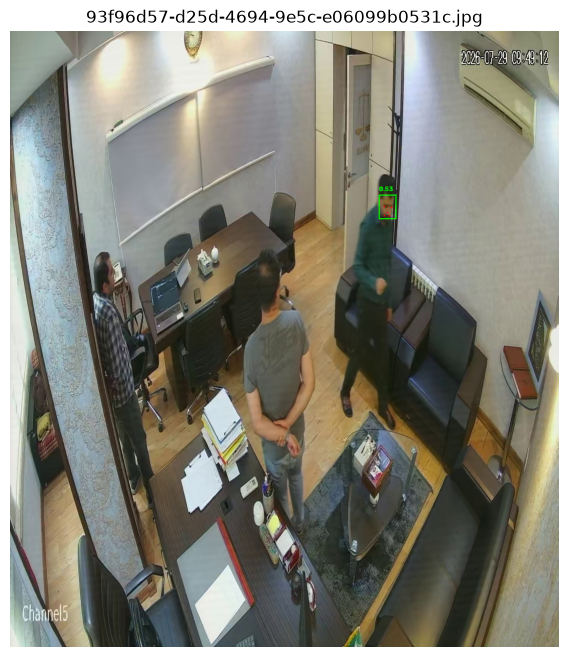

In [12]:
vis = image.copy()
for face in faces:
    x1, y1, x2, y2 = face.bbox.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        vis,
        f"{face.det_score:.2f}",
        (x1, max(y1 - 10, 0)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )
    for x, y in face.kps.astype(int):
        cv2.circle(vis, (x, y), 2, (0, 0, 255), -1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(image_path.name)
plt.show()

/Users/tohid/Development/faceVision/.venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


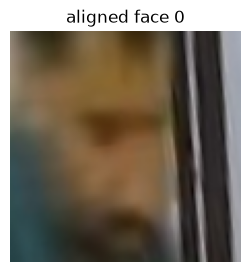

In [13]:
# show the aligned 112x112 crop that would be fed to ArcFace
n = len(faces)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for i, face in enumerate(faces):
        aligned = retina.align(image, face.kps)
        axes[i].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"aligned face {i}")
        axes[i].axis("off")
    plt.show()
else:
    print("no faces detected in this image")

In [14]:
for i, face in enumerate(faces):
    print(f"face {i}: bbox={face.bbox} det_score={face.det_score:.3f} kps={face.kps.tolist()}")

face 0: bbox=[ 968.40857  430.17892 1012.6181   492.1792 ] det_score=0.534 kps=[[981.3700561523438, 460.46771240234375], [1001.9631958007812, 462.3154602050781], [990.898681640625, 476.5618896484375], [982.2769165039062, 483.3748779296875], [995.5436401367188, 484.83856201171875]]
